In [2]:
from pathlib import Path
from scripts.data_processing.storage import load_parquet_df
import pandas as pd


players_df = load_parquet_df("silver_players.parquet")

In [20]:
players_df.columns

Index(['account_id', 'hero_id', 'player_slot', 'team', 'kills', 'deaths',
       'assists', 'net_worth', 'last_hits', 'denies', 'ability_points',
       'assigned_lane', 'player_level', 'player_match_outcome',
       'final_stats.ability_kills', 'final_stats.ability_points',
       'final_stats.absorption_provided', 'final_stats.assists',
       'final_stats.boss_damage', 'final_stats.bullet_kills',
       'final_stats.creep_damage', 'final_stats.creep_kills',
       'final_stats.damage_absorbed', 'final_stats.damage_mitigated',
       'final_stats.deaths', 'final_stats.denies', 'final_stats.gold_boss',
       'final_stats.gold_boss_orb', 'final_stats.gold_death_loss',
       'final_stats.gold_denied', 'final_stats.gold_lane_creep',
       'final_stats.gold_lane_creep_orbs', 'final_stats.gold_neutral_creep',
       'final_stats.gold_neutral_creep_orbs', 'final_stats.gold_player',
       'final_stats.gold_player_orbs', 'final_stats.gold_treasure',
       'final_stats.headshot_kills', 'f

## Question: How different are kills amongst games that were lost or won?
    - Players who win tend to have higher kills

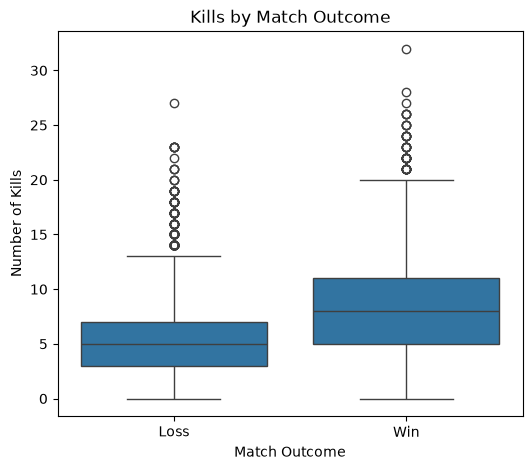

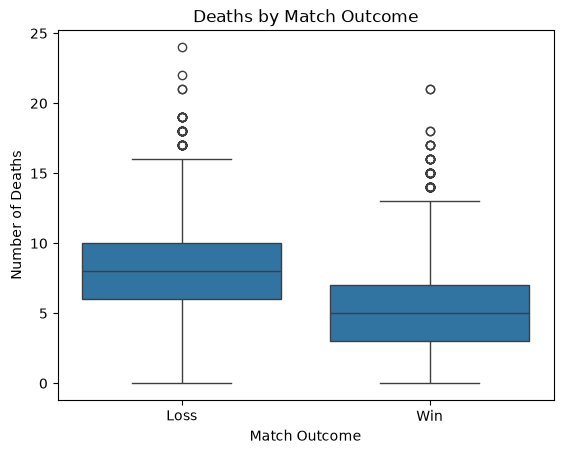

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6, 5))

sns.boxplot(data=players_df, x="player_match_outcome", y="kills")

plt.title("Kills by Match Outcome")
plt.xlabel("Match Outcome")
plt.ylabel("Number of Kills")

plt.show()

sns.boxplot(data=players_df, x="player_match_outcome", y="deaths")

plt.title("Deaths by Match Outcome")
plt.xlabel("Match Outcome")
plt.ylabel("Number of Deaths")

plt.show()

## Question: Does hero chosen associated with winning or losing?

In [37]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(players_df["player_match_outcome"], players_df["hero_id"])
statistic, pvalue, dof, expected_freq = chi2_contingency(contingency_table)

statistic, pvalue, dof, expected_freq

(np.float64(87.70962864469905),
 np.float64(5.310865414117023e-06),
 37,
 array([[249.2729581 , 162.89123995, 149.56377486, 135.24909014,
         142.65323741, 178.19314431,  81.93922979, 151.04460432,
         162.89123995, 100.69640288, 293.69784173,  97.73474397,
         224.5924672 , 147.58933559,  63.67566653, 158.44875159,
         177.20592467, 150.05738468,  78.97757088, 146.10850614,
         244.83046974,  82.92644943, 113.53025815,  60.71400762,
          81.93922979,  67.62454507, 158.44875159, 218.17553957,
         153.01904359, 149.56377486, 206.32890394,  80.45840034,
         149.07016504, 159.92958104, 487.19289039, 156.96792213,
         108.10055015, 100.69640288],
        [255.7270419 , 167.10876005, 153.43622514, 138.75090986,
         146.34676259, 182.80685569,  84.06077021, 154.95539568,
         167.10876005, 103.30359712, 301.30215827, 100.26525603,
         230.4075328 , 151.41066441,  65.32433347, 162.55124841,
         181.79407533, 153.94261532,  81.022

In [49]:
players_df["player_match_outcome"].shape[0]
wins = players_df[players_df["player_match_outcome"] == "Win"]
wins

,account_id,hero_id,player_slot,team,kills,deaths,assists,net_worth,last_hits,denies,...,final_stats.self_healing,final_stats.shots_hit,final_stats.shots_missed,final_stats.teammate_barriering,final_stats.teammate_healing,final_stats.tech_power,final_stats.time_stamp_s,final_stats.weapon_power,mvp_rank,match_id
2,1905391212,27,7,Team1,14,1,10,29319,75,2,...,24683,2085,1027,0,0,93,1512,92,1.0,107597835
3,1034192545,7,8,Team1,10,0,9,36953,148,15,...,2214,4205,2213,0,0,117,1512,104,2.0,107597835
4,1541715265,35,12,Team1,3,2,11,34895,158,3,...,3972,545,697,0,1337,106,1512,95,NaN,107597835
6,970356436,77,11,Team1,3,2,12,26946,151,3,...,8491,509,230,0,0,126,1512,8,NaN,107597835
9,1899984662,64,10,Team1,9,0,13,27893,132,3,...,5086,971,1528,0,0,91,1512,107,NaN,107597835
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11966,296990351,31,8,Team1,5,4,28,30148,51,0,...,5088,1038,697,0,0,162,1764,55,NaN,107495957
11970,335867737,20,11,Team1,10,0,22,37944,173,8,...,22079,4216,3206,0,8018,70,1764,142,1.0,107495957
11972,1056791779,77,7,Team1,9,0,20,34841,105,8,...,17165,527,238,0,0,211,1764,15,NaN,107495957
11974,1065885675,13,12,Team1,6,6,17,32615,139,4,...,7541,3465,2286,0,0,123,1764,80,NaN,107495957


In [60]:
import requests
import pandas as pd

BASE = "https://api.deadlock-api.com"
HEADERS = {"User-Agent": "python-requests (deadlock-exploration-script)"}

r = requests.get(f"{BASE}/v1/assets/heroes", headers=HEADERS, timeout=30)
r.raise_for_status()
hero_names = pd.DataFrame(r.json())[["id", "name"]].rename(columns={"id": "hero_id", "name": "hero_name"})

players_df = players_df.merge(hero_names, on="hero_id", how="left")

In [61]:
players_df

,account_id,hero_id,player_slot,team,kills,deaths,assists,net_worth,last_hits,denies,...,final_stats.shots_hit,final_stats.shots_missed,final_stats.teammate_barriering,final_stats.teammate_healing,final_stats.tech_power,final_stats.time_stamp_s,final_stats.weapon_power,mvp_rank,match_id,hero_name
0,3167906,11,4,Team0,0,4,0,16571,106,0,...,623,432,0,184,82,1512,0,NaN,107597835,Dynamo
1,107896103,19,3,Team0,3,10,1,16753,69,7,...,1522,1238,0,0,72,1512,65,NaN,107597835,Shiv
2,1905391212,27,7,Team1,14,1,10,29319,75,2,...,2085,1027,0,0,93,1512,92,1.0,107597835,Yamato
3,1034192545,7,8,Team1,10,0,9,36953,148,15,...,4205,2213,0,0,117,1512,104,2.0,107597835,Wraith
4,1541715265,35,12,Team1,3,2,11,34895,158,3,...,545,697,0,1337,106,1512,95,NaN,107597835,Viscous
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11810,1481447935,60,3,Team0,7,8,3,26123,107,2,...,528,391,0,0,165,1764,35,3.0,107495957,Sinclair
11811,1056791779,77,7,Team1,9,0,20,34841,105,8,...,527,238,0,0,211,1764,15,NaN,107495957,Apollo
11812,182145792,4,6,Team0,1,4,0,31220,187,0,...,367,112,0,0,144,1764,67,NaN,107495957,Lady Geist
11813,1065885675,13,12,Team1,6,6,17,32615,139,4,...,3465,2286,0,0,123,1764,80,NaN,107495957,Haze


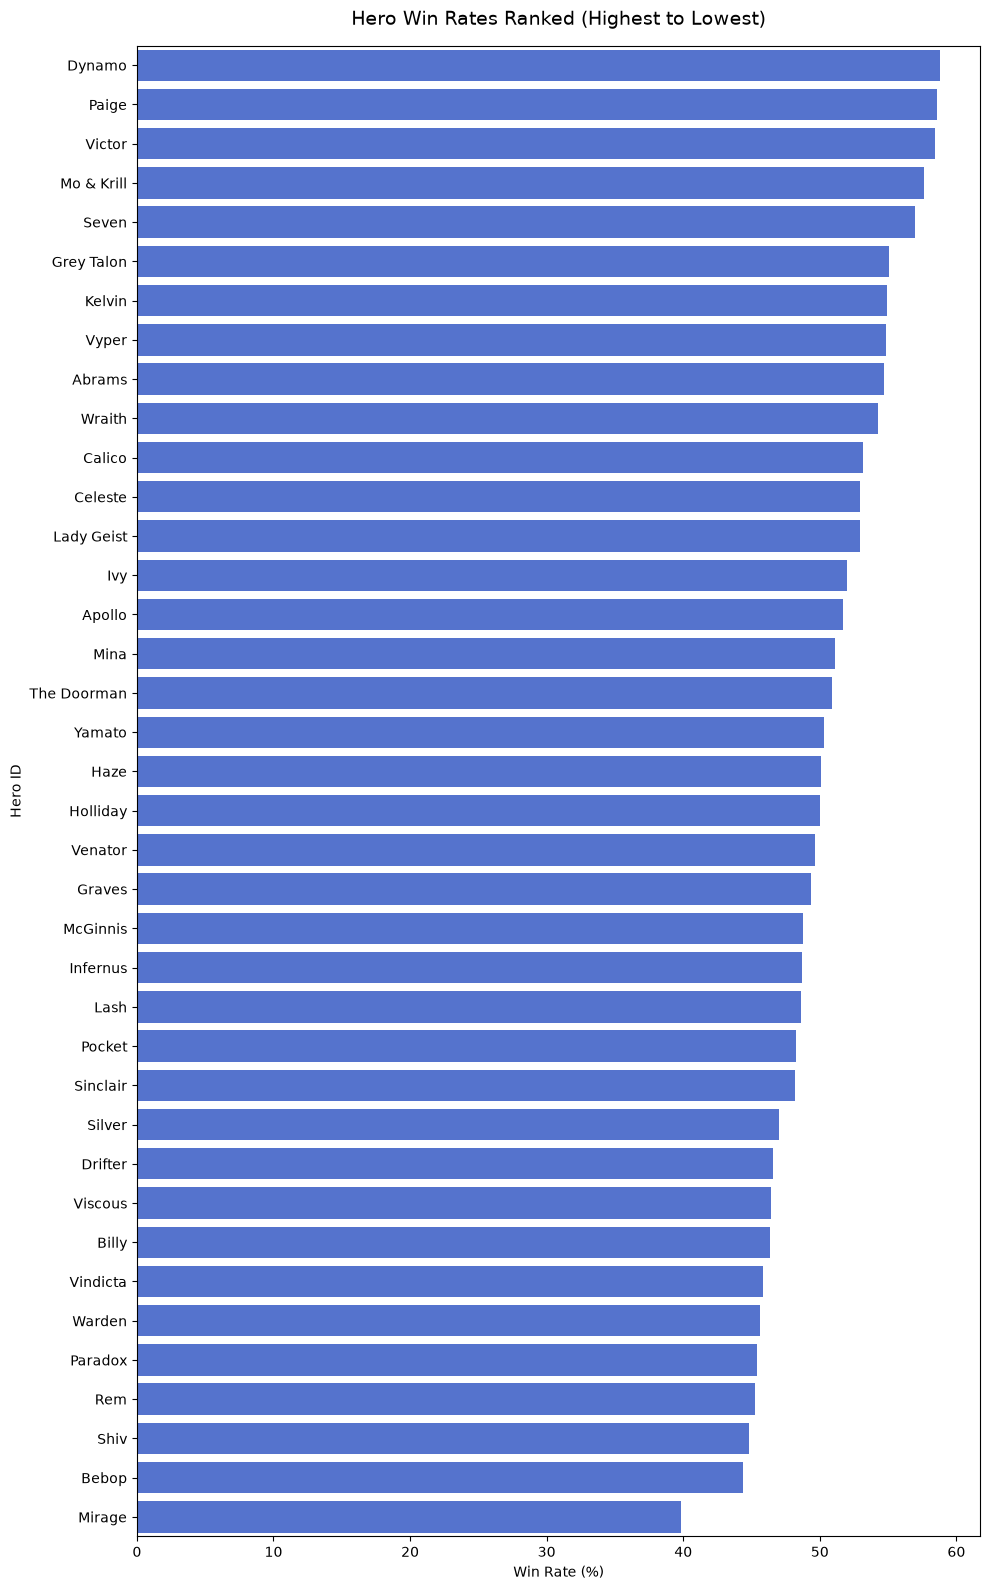

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

win_rates_df = (
    players_df.groupby("hero_name")["player_match_outcome"]
    .apply(lambda x: (x == "Win").mean() * 100)
    .sort_values(ascending=False)
    .reset_index(name="win_rate")  # Turns it into a DataFrame with columns: 'hero_id' and 'win_rate'
)

plt.figure(figsize=(10, 16))

sns.barplot(
    data=win_rates_df,
    x="win_rate",
    y="hero_name",
    orient="h",
    order=win_rates_df["hero_name"],  # Explicitly enforces the exact highest-to-lowest order
    color="royalblue"
)

plt.title("Hero Win Rates Ranked (Highest to Lowest)", fontsize=14, pad=15)
plt.xlabel("Win Rate (%)")
plt.ylabel("Hero ID")
plt.tight_layout()
plt.show()
